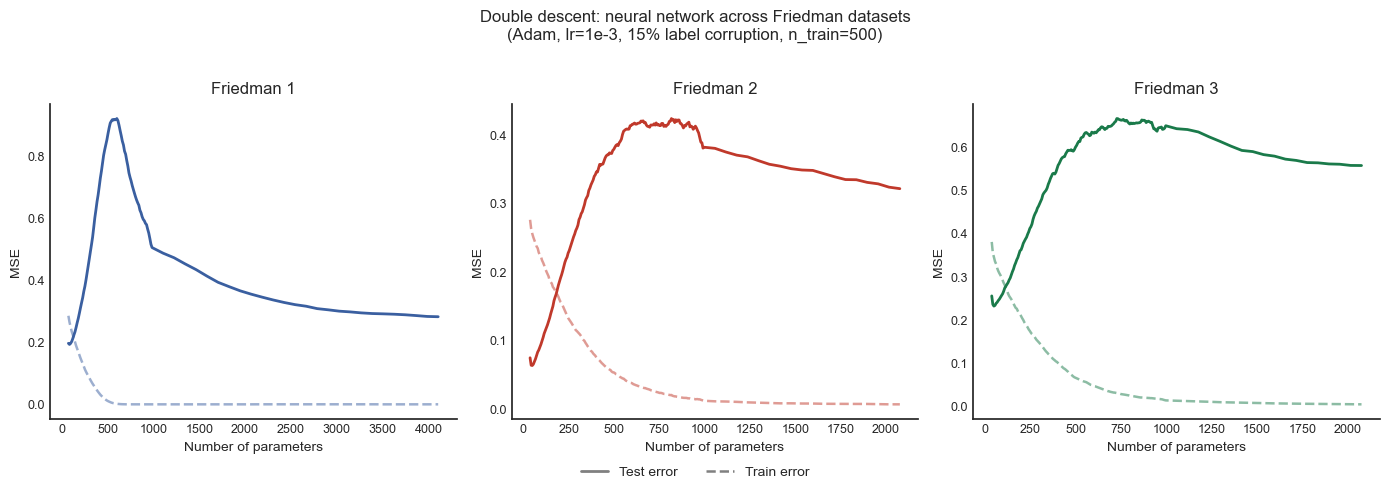

[INFO] Saved to full_runs/adam_corruption0.15/figure2_main_results.png.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')

# The nn run that produced the best results
BASE_DIR = Path("full_runs/adam_corruption0.15")

def smooth(y, window=11):
    return np.convolve(y, np.ones(window)/window, mode='same')

def load_dataset(dataset):
    path = os.path.join(BASE_DIR, f"{dataset}_metrics_summary.csv")
    df = pd.read_csv(path)
    x = df["params_mean"].values
    train = df["train_mse_mean"].values
    test = df["test_mse_mean"].values
    idx = np.argsort(x)
    return x[idx], train[idx], test[idx]

datasets = ["friedman1", "friedman2", "friedman3"]
titles = ["Friedman 1", "Friedman 2", "Friedman 3"]
colors= ['#3A5FA0', '#C0392B', '#1A7A4A']

trim = 5
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
fig.patch.set_facecolor('white')

for ax, dataset, title, color in zip(axes, datasets, titles, colors):
    x, train, test = load_dataset(dataset) 

    train_s = smooth(train, window=11)[trim:-trim]
    test_s = smooth(test, window=11)[trim:-trim]
    x_s = x[trim:-trim]

    ax.plot(x_s, test_s, linewidth=2.0, linestyle='-', color=color, label='Test error')
    ax.plot(x_s, train_s, linewidth=1.8, linestyle='--', color=color, label='Train error', alpha=0.5)

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel('Number of parameters', fontsize=10)
    ax.set_ylabel('MSE', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

"""
# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.05))
"""
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=2.0, linestyle='-', label='Test error'),
    Line2D([0], [0], color='gray', linewidth=1.8, linestyle='--', label='Train error')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Double descent: neural network across Friedman datasets\n(Adam, lr=1e-3, 15% label corruption, n_train=500)',
             fontsize=12, y=1.02)

plt.tight_layout()
out_path = BASE_DIR / "figure2_main_results.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f"[INFO] Saved to {out_path}.")